# What Drives Childhood Obesity? 
An Explainable Machine Learning Analysis of London Wards

## Preparation

- [Github link](https://github.com/mixedmint/DSSS)

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: Podman

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **xgboost-3.2.0**
    - **shap-0.51.0**

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

In [1]:
import time
start_time = time.time()

In [2]:
import pandas as pd
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import numpy as np
from matplotlib import pyplot 
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

思路：
1. background：
   （1）儿童Obesity具有普遍和严重性, 是重要的城市健康问题 (Colmenarejo, 2020)。
   （2）结合具体数据，写一下UK/London儿童肥胖率
3. LR（method和features）：
   （1）为了预防儿童肥胖，选取特征指标进行开发预测模型至关重要。目前学界模型主要分为Statistical Models和Machine Learning Models两种。
   （2）进行Statistical Models综述：
       a.主流为logistic regression和linear regression。
       b. 写一条综述：Z Pei(2013)分别采用线性回归模型和逻辑回归模型评估了early life ris factors风险因素（出生体重、父母受教育程度、家庭收入以及母亲孕期吸烟情况）对德国儿童10岁时BMI和超重的影响。
   (3)Machine Learning Models综述：
       a. Siwoo Jeong (2023)研究了the combined influence of individual and social/environmental factors on obesity in 首尔。对于个人因素，采用RF model预测Obesity并用SHAP探究features重要性；使用GWLASSO来计算社会/环境因素对肥胖率的影响。
       b. Hammond(2019)使用electronic health records (individual factors)和数据，employed LASSO regression, random forest regression, and gradient boosting regression，来分别预测NYC男女孩五岁时的肥胖概率。
    (4)总结上述综述：使用不同方法，都从individual factors（指出生时体重等这种个人信息）和public（不确定用哪个词，就是指人口统计、社会经济等因素）两个层面建立指标体系来预测特定年龄段儿童肥胖率。
    (5)提出research gap：缺乏不同年龄段的比较。由此简单引出我们的研究（一句话概括）。

word: 249

Childhood obesity has emerged as a pressing global public health challenge, closely linked to severe lifelong comorbidities such as type II diabetes (Colmenarejo, 2020). In the UK, childhood obesity prevalence varies significantly across different neighborhoods and worsens dramatically as children age, rising from approximately 10.5% in Reception to over 22.2% by Year 6 (NCMP, 2025). This issue is particularly acute in urban settings like London.

To mitigate this crisis, developing robust predictive models using multidimensional risk factors is crucial. Traditionally, statistical approaches such as linear and logistic regression have been widely employed to evaluate early life risk factors (Pei et al., 2013). However, childhood obesity is a highly complex condition driven by interacting individual and area-level characteristics. Consequently, recent literature has shifted towards Machine Learning (ML) models capable of capturing these nonlinear relationships. For instance, Hammond et al. (2019) demonstrated the superiority of Gradient Boosting over traditional regression in predicting obesity, while Jeong et al. (2023) successfully utilized Random Forest coupled with SHAP to interpret the complex influences of social and environmental factors.

Despite these methodological advancements, a critical research gap remains. Existing studies predominantly focus on single age cohorts or rely heavily on individual-level clinical data. There is a lack of comparative analysis exploring how the relative predictive importance of area-level socioeconomic and built environment factors shifts across different developmental stages. Addressing this, this study employs MLR, RF, XGBoost, and SHAP to compare how ward-level characteristics drive childhood obesity differently between Reception and Year 6 cohorts in London.

## Research questions

[[ go back to the top ]](#Table-of-contents)

words: 62
- RQ1 (预测)：在伦敦 Ward 层级上，包含社会经济、人口统计、健康状况与环境暴露在内的多维特征，在多大程度上能够准确预测不同学龄（Reception 与 Year 6）儿童的肥胖率？（VIF→MLR→RF/XGBoost）

- RQ2 (特征归因与解释)：在最优的预测模型中，哪些特征对儿童肥胖率具有最显著的驱动作用？这些关键驱动因素的边际效应（Marginal effects）在两个不同学龄群体之间呈现出怎样的差异？（SHAP）

<div style="margin-left: 2em;">
<span style="font-family: monospace;">
    RQ1 | To what extent can multidimensional features (socioeconomic, demographic, health, and environmental exposure factors) accurately predict the obesity rates of children in different school years at the London ward level?
</span>
</div>

<div style="margin-left: 2em;">
<span style="font-family: monospace;">
    RQ2 | Within the optimal predictive model, which key features act as the most significant drivers of childhood obesity, and how do their marginal effects differ between the two age groups?
</span>
</div>

## Data

[[ go back to the top ]](#Table-of-contents)

### Data Source
word:66

The dependent variable is sourced from the London Ward-level [Prevalence of Childhood Obesity](https://data.london.gov.uk/dataset/prevalence-of-childhood-obesity-borough-ward-and-msoa-23g07/) dataset (2010/11–2012/13), which provides overweight and obesity prevalence for Reception and Year 6 cohorts across over 600 wards.

For independent variables, the [London Ward Atlas](https://data.london.gov.uk/dataset/ward-profiles-and-atlas-exprl/) was utilized due to its comprehensive coverage of area-level statistics. Due to privacy constraints associated with individual clinical data, this study focuses exclusively on macroscopic neighborhood characteristics.

### Feature Selection
word:63

Guided by recent literature, feature selection was conducted across four dimensions: **demographic, socioeconomic, health condition, and environmental exposure**. While Mazza et al. (2025) emphasize the predictive power of standard socioeconomic and demographic indicators, this study further incorporates environmental and health behavior metrics to broaden the analytical scope, an approach supported by Salerno et al. (2024). 

This theoretically driven selection yielded 23 initial predictors.

| Variable                            | Type         | Description                                                             |Year   |
|-------------------------------------|--------------|-------------------------------------------------------------------------|---|
|**Target Variables** |  |  |  |
| Childhood obesity rate: reception (aged 4-5 years) and year 6 (aged 10-11 years) | Numeric | The children obesity rate of wards  | 2010/11-2012/13 |
| | | | |
| **Demographic Features** |   |                                     |   |
| Median age | Numeric | Median age of wards | 2011 |
| Population under 15 years | Numeric | Percentage of population age 15 years or younger | 2013 |
| Population density | Numeric | Population density (persons per sq km) | 2011 |
| White population | Numeric | Percentage of White population | 2011 |
| Population borned in UK  | Numeric  | Percentage of population borned in UK                                    | 2011  |
| | | | |
| **Socioeconomic Features**  |   |                                   |   |
| Median house price | Numeric | The median house price (UK pounds) of wards | 2011 |
| Homeownership | Numeric | Percentage of owner-occupied housing units | 2011 |
| Median household income | Numeric | The income (UK pound) where half of households in a county earn more and half of households earn less | 2012 |
| Children in Single-Parent Household | Numeric  | Percentage of children that live in a household headed by a single parent | 2011 |
| Parents unempolyment | Numeric | Percentage of households with no adults in employment with dependent children | 2011 |
| Higher education qulifications | Numeric | Percentage of people with level 4 qulifications and above | 2011 |
| Housing benefits claimants | Numeric | Percentage of households that claim housing benefits | 2011 |
| Children in poverty | Numeric | Percentage of people under age 16 in poverty | 2011 |
| Crime rate | Numeric | Crime rate of wards | 2011 |
| Indices of Deprivation | Numeric | Average scores of Indices of Deprivation | 2010 |
| Income Deprivation Affecting Children Index (IDACI) | Numeric | Average scores of IDACI | 2010 |
| | | | |
| **Health Condition Features**  |   |                                   |  |
| Life expectancy  | Numeric  | Average life expectancy at birth of all genders | 2009-2013  |
| Subjective well-being average score  | Numeric | Subjective well-being average score of wards | 2011-2013 |
| People with Bad or Very Bad Health | Numeric | Percentage of people with Bad or Very Bad Health | 2011 |
| | | | |
| **Environmental Exposure Features**  |   |                                   |  |
| Air emissions | Numeric  | Annual Mean of Nitrogen Oxide (NOx) | 2011  |
| Deficiency in access to green space | Numeric | Percentage of homes with deficiency in access to nature | 2012 |
| Public Transport Accessibility | Numeric | Average PTAL score | 2011 |
| Car access | Numeric | Cars per household | 2011 |

### Data Pre-processing and Presentation
word: 89

The workflow was executed in the following steps:

1.	_Target Formatting & Cleaning_: Converted target variables to numeric formats (coercing character errors to NaN) and removed rows with missing entries.
2.	_Feature Engineering_: Computed proportional rates from absolute feature counts to standardize the scale across different wards.
3.	_Data Integration_: Merged the cleaned feature set ($X$) and target variables ($y$) via an inner join based on the unique Ward Code.
4.	_Exploratory Data Analysis (EDA)_: Conducted statistical summaries and spatial mapping to contextualize the data structures and variable distributions.

#### Prevalence of Childhood Obesity

In [3]:
# Load childhood obesity prvalance data
obesity = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/children_obesity_2010-2013.csv")
obesity.head(10)

,Code,Borough,Names,obesity rate % (age 4-5),obesity rate % (age 10-11)
0,E05000001,City of London,Aldersgate,s,s
1,E05000015,City of London,Cripplegate,s,s
2,E05000017,City of London,Farringdon Within,s,s
3,E05000021,City of London,Portsoken,s,s
4,E05000026,Barking and Dagenham,Abbey,15.1%,23.2%
5,E05000027,Barking and Dagenham,Alibon,9.6%,25.6%
6,E05000028,Barking and Dagenham,Becontree,12.1%,28.4%
7,E05000029,Barking and Dagenham,Chadwell Heath,12.1%,28.8%
8,E05000030,Barking and Dagenham,Eastbrook,10.9%,24.1%
9,E05000031,Barking and Dagenham,Eastbury,12.3%,24.3%


In [4]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Code                        628 non-null    object
 1   Borough                     628 non-null    object
 2   Names                       628 non-null    object
 3   obesity rate % (age 4-5)    628 non-null    object
 4   obesity rate % (age 10-11)  628 non-null    object
dtypes: object(5)
memory usage: 24.7+ KB


In [5]:
# Since suppressed data is marked with `s` for privacy,
# the obesity rate columns are parsed as object instead of float.
# We will convert them to numeric types and drop any NaN rows

# First, simplify complex column names
obesity = obesity.rename({'obesity rate % (age 4-5)': 'Reception', 'obesity rate % (age 10-11)': 'Year 6'}, axis=1)

# Then convert obesity rate columns from strings to floats
cols_to_clean = ['Reception', 'Year 6']
for col in cols_to_clean:
    obesity[col] = pd.to_numeric(obesity[col].str.replace('%', ''), errors='coerce')

# Drop rows with NaN values and Borough column
obesity = obesity.dropna().drop(['Borough'], axis=1)

obesity.head()

,Code,Names,Reception,Year 6
4,E05000026,Abbey,15.10,23.20
5,E05000027,Alibon,9.60,25.60
6,E05000028,Becontree,12.10,28.40
7,E05000029,Chadwell Heath,12.10,28.80
8,E05000030,Eastbrook,10.90,24.10


In [6]:
# Check data types of obesity rates after processing
obesity.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 4 to 626
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Code       609 non-null    object 
 1   Names      609 non-null    object 
 2   Reception  609 non-null    float64
 3   Year 6     609 non-null    float64
dtypes: float64(2), object(2)
memory usage: 23.8+ KB


#### Features

In [7]:
# Load features data
raw_features = pd.read_csv("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/selected_ward_atlas.csv")
raw_features.head()

,New Code,Borough,Names,Median age,Aged 0-15,Population density,White,Mixed,Asian or Asian British,Black or Black British,...,% Highest level of qualification: Level 4 qualifications and above,Housing benefits claimants,Children in poverty,Crime rate,Air emissions,% homes with deficiency in access to nature,Public transport accessibility,Car access,Indices of Deprivation,IDACI
0,E09000001,City of London,City of London,39,7.50,2312.50,5799,289,940,193,...,68.40,6.46,13.90,611.90,94.87,100.00,7.68,0.39,12.12,0.12
1,E05000026,Barking and Dagenham,Abbey,29,25.27,9884.62,3596,585,5619,2621,...,34.50,15.20,34.50,182.57,53.79,2.16,5.85,0.55,32.73,0.44
2,E05000027,Barking and Dagenham,Alibon,32,25.96,7464.29,7275,362,743,1900,...,16.70,19.04,35.70,91.39,41.69,71.73,3.26,0.82,36.07,0.40
3,E05000028,Barking and Dagenham,Becontree,32,24.90,8923.08,6789,524,2009,2048,...,20.60,16.91,34.30,98.79,44.00,17.17,2.85,0.87,31.69,0.38
4,E05000029,Barking and Dagenham,Chadwell Heath,34,24.14,2970.59,6224,473,1560,1593,...,19.50,14.82,35.60,97.43,39.47,63.59,2.26,0.92,38.04,0.44


In [8]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 36 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   New Code                                                              625 non-null    object 
 1   Borough                                                               625 non-null    object 
 2   Names                                                                 625 non-null    object 
 3   Median age                                                            625 non-null    int64  
 4   Aged 0-15                                                             625 non-null    float64
 5   Population density                                                    625 non-null    float64
 6   White                                                                 625 non-null    int64  
 7  

In [9]:
# Calculate the percentage of White population 
# Define ethnicity columns
ethnicity_cols = [
    'White', 
    'Mixed', 
    'Asian or Asian British', 
    'Black or Black British', 
    'Other'
]

# Calculate White population percentage
raw_features['White population'] = (raw_features['White'] / raw_features[ethnicity_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(ethnicity_cols, axis=1)

raw_features['White population'].head()

0   78.63
1   28.12
2   70.05
3   58.80
4   62.11
Name: White population, dtype: float64

In [10]:
# Calculate the percentage of population borned in UK
raw_features['Born in uk'] = (raw_features['Born in UK'] / raw_features[['Born in UK', 'Not Born in UK']].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(['Born in UK', 'Not Born in UK'], axis=1)

raw_features['Born in uk'].head()

0   63.32
1   42.70
2   75.34
3   69.94
4   75.23
Name: Born in uk, dtype: float64

In [11]:
# Calculate the percentage of owner-occupied housing units (Homeownership)
# Define ownership columns
owenership_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)', 
    'Social rented', 
    'Private rented', 
    'Rent Free'
]

# Define Owner-occupied housing columns
owned_cols = [
    'Owned: Owned outright', 
    'Owned: Owned with a mortgage or loan (inc shared)'
]

# Calculate Homeownership
raw_features['Homeownership'] = (raw_features[owned_cols].sum(axis=1) / raw_features[owenership_cols].sum(axis=1))*100

# Drop the original data columns
raw_features = raw_features.drop(owenership_cols, axis=1)

raw_features['Homeownership'].head()

0   42.60
1   33.79
2   46.56
3   48.94
4   54.49
Name: Homeownership, dtype: float64

In [12]:
# Calculate the percentage of Children in Single-Parent Household
raw_features['Children in single-parent household'] = (raw_features['Lone parent'] / raw_features['All Households'])*100

# Drop the original data columns
raw_features = raw_features.drop(['Lone parent', 'All Households'], axis=1)

raw_features['Children in single-parent household'].head()

0    3.49
1   14.17
2   20.95
3   20.58
4   19.69
Name: Children in single-parent household, dtype: float64

In [13]:
# Simplify complex column names
raw_features = raw_features.rename({'Subjective well-being average score': 'Well-being score',
                                    'People with Bad or Very Bad Health': 'People in bad health',
                                    '% of households with no adults in employment with dependent children': 'Parents unemployment', 
                                    '% Highest level of qualification: Level 4 qualifications and above': 'Higher education qualifications',
                                   '% homes with deficiency in access to nature': 'Green deficit'},
                                   axis=1)

In [14]:
raw_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625 entries, 0 to 624
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   New Code                             625 non-null    object 
 1   Borough                              625 non-null    object 
 2   Names                                625 non-null    object 
 3   Median age                           625 non-null    int64  
 4   Aged 0-15                            625 non-null    float64
 5   Population density                   625 non-null    float64
 6   Life expectancy                      625 non-null    float64
 7   Well-being score                     625 non-null    float64
 8   People in bad health                 625 non-null    float64
 9   Median house price                   625 non-null    float64
 10  Median household income              625 non-null    int64  
 11  Parents unemployment            

#### Joining the Datasets

In [15]:
# Merge two databases based on the ward code
df = pd.merge(obesity, raw_features, left_on='Code', right_on='New Code', how='inner')

# Remove duplicate and unnecessary columns
df = df.drop(['New Code', 'Borough', 'Names_y'], axis=1).rename({'Names_x': 'Names'}, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Code                                 609 non-null    object 
 1   Names                                609 non-null    object 
 2   Reception                            609 non-null    float64
 3   Year 6                               609 non-null    float64
 4   Median age                           609 non-null    int64  
 5   Aged 0-15                            609 non-null    float64
 6   Population density                   609 non-null    float64
 7   Life expectancy                      609 non-null    float64
 8   Well-being score                     609 non-null    float64
 9   People in bad health                 609 non-null    float64
 10  Median house price                   609 non-null    float64
 11  Median household income         

In [16]:
df.describe()

,Reception,Year 6,Median age,Aged 0-15,Population density,Life expectancy,Well-being score,People in bad health,Median house price,Median household income,...,Air emissions,Green deficit,Public transport accessibility,Car access,Indices of Deprivation,IDACI,White population,Born in uk,Homeownership,Children in single-parent household
count,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,...,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00,609.00
mean,10.47,21.58,34.25,19.78,8014.41,81.90,7.63,4.98,308727.61,38680.76,...,51.70,25.94,3.62,0.85,25.24,0.31,60.85,64.34,51.08,12.75
std,3.20,5.04,4.01,3.57,4757.47,2.17,0.32,1.23,124331.31,6483.09,...,11.22,30.37,1.29,0.33,11.19,0.15,18.98,13.64,18.46,4.43
min,2.60,6.20,26.00,6.87,177.59,75.98,6.78,2.10,120000.00,25090.00,...,30.62,0.00,1.28,0.23,4.88,0.04,6.26,31.55,13.72,4.37
25%,8.30,18.50,31.00,17.76,4528.57,80.41,7.40,4.10,225500.00,33540.00,...,43.63,0.09,2.62,0.56,15.69,0.19,47.38,54.69,35.17,9.32
50%,10.50,22.20,33.00,19.61,6750.00,81.87,7.64,4.90,275000.00,38060.00,...,49.56,12.46,3.25,0.83,24.73,0.31,63.11,63.09,49.85,12.14
75%,12.50,25.40,37.00,21.88,10735.29,83.32,7.88,5.80,356250.00,42880.00,...,57.67,42.87,4.36,1.12,33.61,0.42,76.02,73.87,65.78,15.55
max,20.90,35.70,46.00,32.40,29375.00,89.78,8.55,10.90,1200000.00,58400.00,...,99.70,100.00,7.96,1.71,54.78,0.78,95.87,94.95,90.99,31.43


#### Exploratory Data Analysis (EDA)

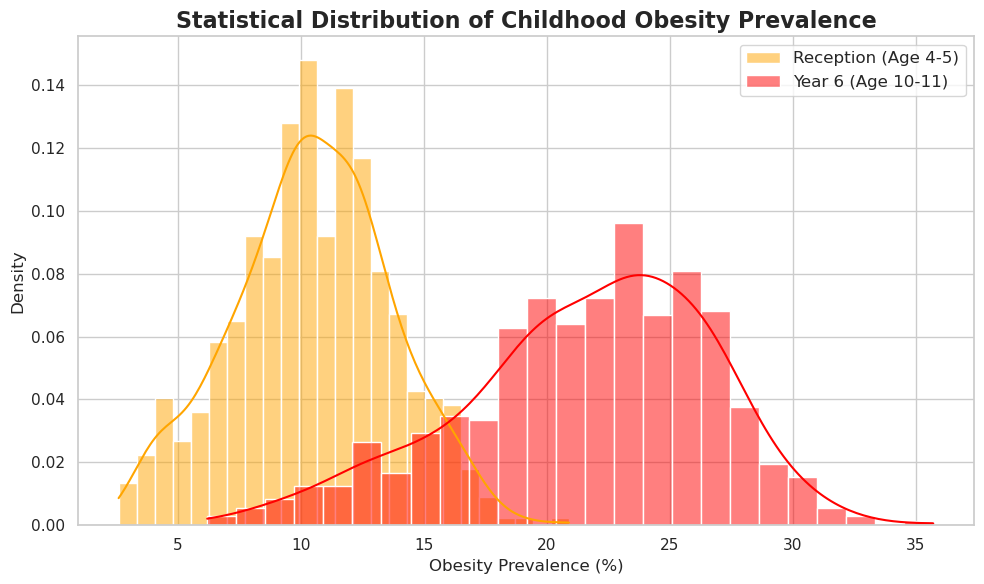

In [17]:
# Plot statistical disttribution chart of obesity prevalence 

# Set figure size and theme
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Reception obesity histogram+KDE
sns.histplot(
    df['Reception'], 
    kde=True, 
    color='orange', 
    label='Reception (Age 4-5)', 
    stat='density', 
    alpha=0.5,      
    bins=25
)

# Year 6 obesity histogram+KDE
sns.histplot(
    df['Year 6'], 
    kde=True, 
    color='red', 
    label='Year 6 (Age 10-11)', 
    stat='density', 
    alpha=0.5, 
    bins=25
)

# Configure title and axis labels
plt.title('Statistical Distribution of Childhood Obesity Prevalence', fontsize=16, fontweight='bold')
plt.xlabel('Obesity Prevalence (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add legend
plt.legend(fontsize=12)

# Set layout and show plot
plt.tight_layout()
plt.show()

The noticeable rightward shift of the Year 6 peak clearly indicates a significant increase in obesity prevalence as children age. Additionally, both distributions appear approximately normal with a slight right-skewness.

In [18]:
# Then I will plot choropleth maps of childhood obesity rates to see their spatial distribution patterns

# I downloaded 2011 UK Ward Boundaries files from ONS
# and selected all London wards:

# uk_wards = gpd.read_file('data/Wards_December_2011_GCB.geojson')
# lookup_table = pd.read_csv('data/Wards_and_Local_Authorities_(2011)_to_Wards_and_Local_Authorities_(2022)_Lookup_in_England_and_Wales.csv')
# lookup_table = lookup_table.drop_duplicates(subset=['WD11CD'])
# merged_wards = uk_wards.merge(lookup_table, left_on='wd11cd', right_on='WD11CD', how='left')
# london_wards = merged_wards[merged_wards['LAD11CD'].str.startswith('E09', na=False)]
# columns_to_drop = ['WD11CD', 'WD11NM', 'WD22CD', 'WD22NM', 'LAD22CD', 'LAD22NM']
# london_wards = london_wards.drop(columns=columns_to_drop)

# Load London Ward geojson file
london_map = gpd.read_file("https://raw.githubusercontent.com/mixedmint/DSSS/refs/heads/main/data/london_wards_2011.geojson")
london_map.info()


# Merge london_map and dataset
geo_df = london_map.merge(df, left_on='wd11cd', right_on='Code', how='left')

# Set CRS
geo_df = geo_df.to_crs(epsg=27700)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   OBJECTID  649 non-null    int32   
 1   wd11cd    649 non-null    object  
 2   wd11nm    649 non-null    object  
 3   LAD11NM   649 non-null    object  
 4   geometry  649 non-null    geometry
dtypes: geometry(1), int32(1), object(3)
memory usage: 22.9+ KB


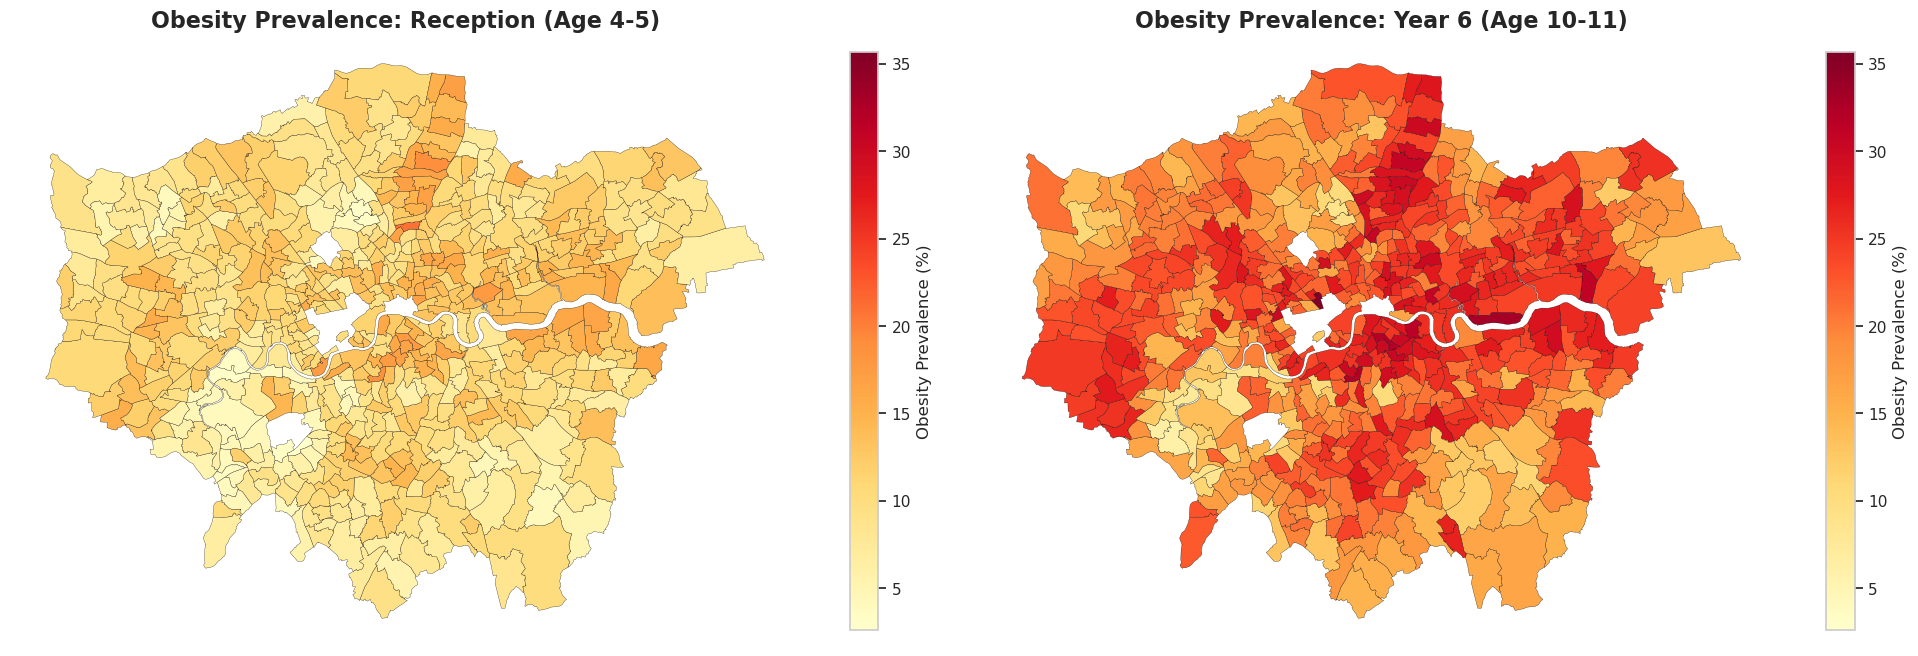

In [19]:
# Plot childhood obesity prevalance choropleth maps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

vmin = min(geo_df['Reception'].min(), geo_df['Year 6'].min())
vmax = max(geo_df['Reception'].max(), geo_df['Year 6'].max())

plot_kwds = {
    'cmap': 'YlOrRd',         
    'vmin': vmin,             
    'vmax': vmax,            
    'edgecolor': 'black',      
    'linewidth': 0.2,         
    'legend': True,
    'legend_kwds': {'shrink': 0.6, 'label': 'Obesity Prevalence (%)'} 
}

# Reception obesity map
geo_df.plot(column='Reception', ax=ax1, **plot_kwds)
ax1.set_title('Obesity Prevalence: Reception (Age 4-5)', fontsize=16, fontweight='bold')
ax1.axis('off')

# Year 6 obesity map
geo_df.plot(column='Year 6', ax=ax2, **plot_kwds)
ax2.set_title('Obesity Prevalence: Year 6 (Age 10-11)', fontsize=16, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

The maps also reveal a stark age-related increase in obesity, with high-prevalence clusters persistently concentrated in central-eastern London wards.

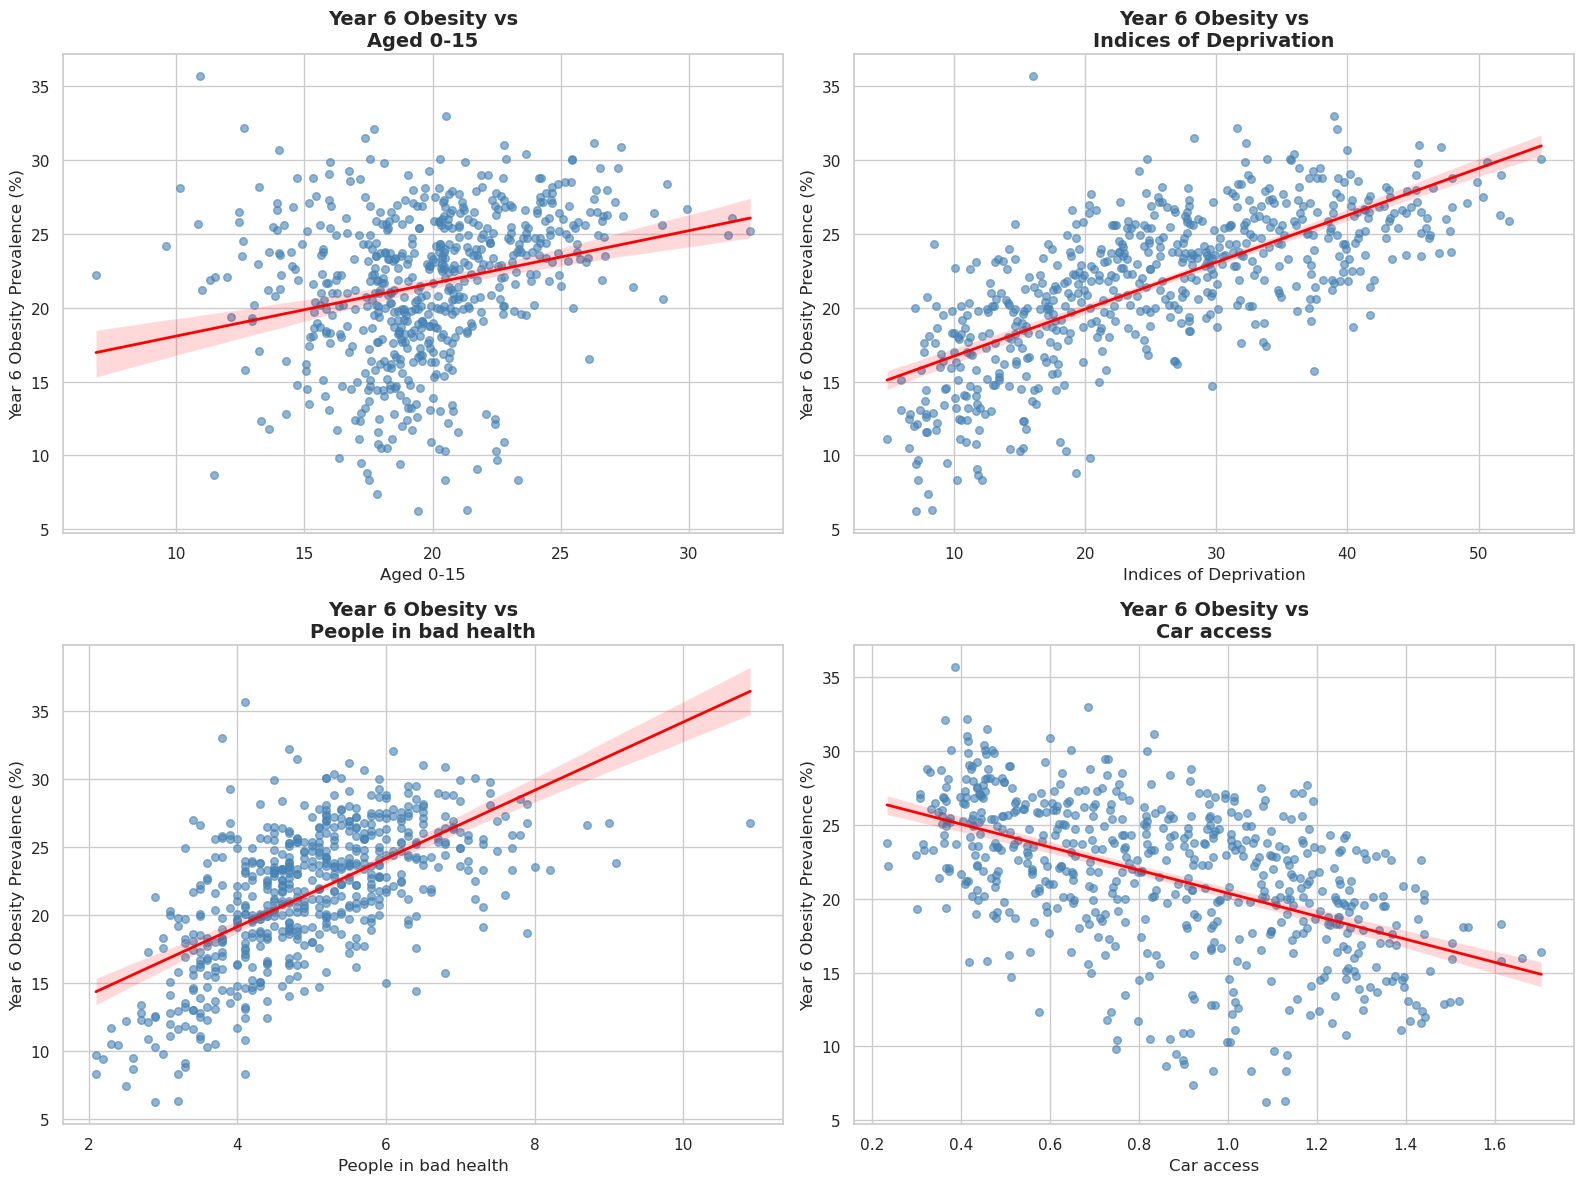

In [20]:
# Plot scatter plots to explore the correlation between obesity prevalence and features

# Since we have 23 features in total
# Plotting all of them would be visually overwhelming and difficult to interpret
# Therefore, we select 4 representative features
selected_features = [
    'Aged 0-15',                 # From demographic dimension      
    'Indices of Deprivation',    # From socioeconomic dimension            
    'People in bad health',      # From health condition dimension
    'Car access'                 # From environmental exposure dimension
]

# Set figure size and theme
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() 

sns.set_theme(style="whitegrid")

# Iterate through each selected feature to plot its relationship with Year 6 obesity
for i, feature in enumerate(selected_features):
    sns.regplot(
        data=df, 
        x=feature, 
        y='Year 6',  # Using Year 6 as the target variable for demonstration as it exhibits more significant variance
        ax=axes[i],
        scatter_kws={'alpha': 0.6, 'color': 'steelblue', 's': 30}, 
        line_kws={'color': 'red', 'linewidth': 2}                  
    )
    
    # Configure titles and axis labels for each subplot
    axes[i].set_title(f'Year 6 Obesity vs\n{feature}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Year 6 Obesity Prevalence (%)', fontsize=12)

plt.tight_layout()
plt.show()

The scatter plots reveal distinct linear patterns across all four dimensions. Indices of Deprivation and People in bad health show the strongest positive associations with Year 6 obesity prevalence, while Car access exhibits a negative relationship, likely because car ownership acts as a proxy for higher socioeconomic status and lower deprivation. Aged 0-15 shows a weaker positive trend. 

However, considerable scatter around all regression lines implies the presence of nonlinear dynamics and interaction effects that simple linear models cannot fully capture. **This motivates the use of MLR as an interpretable baseline, alongside RF and XGBoost to model these more complex structures.**

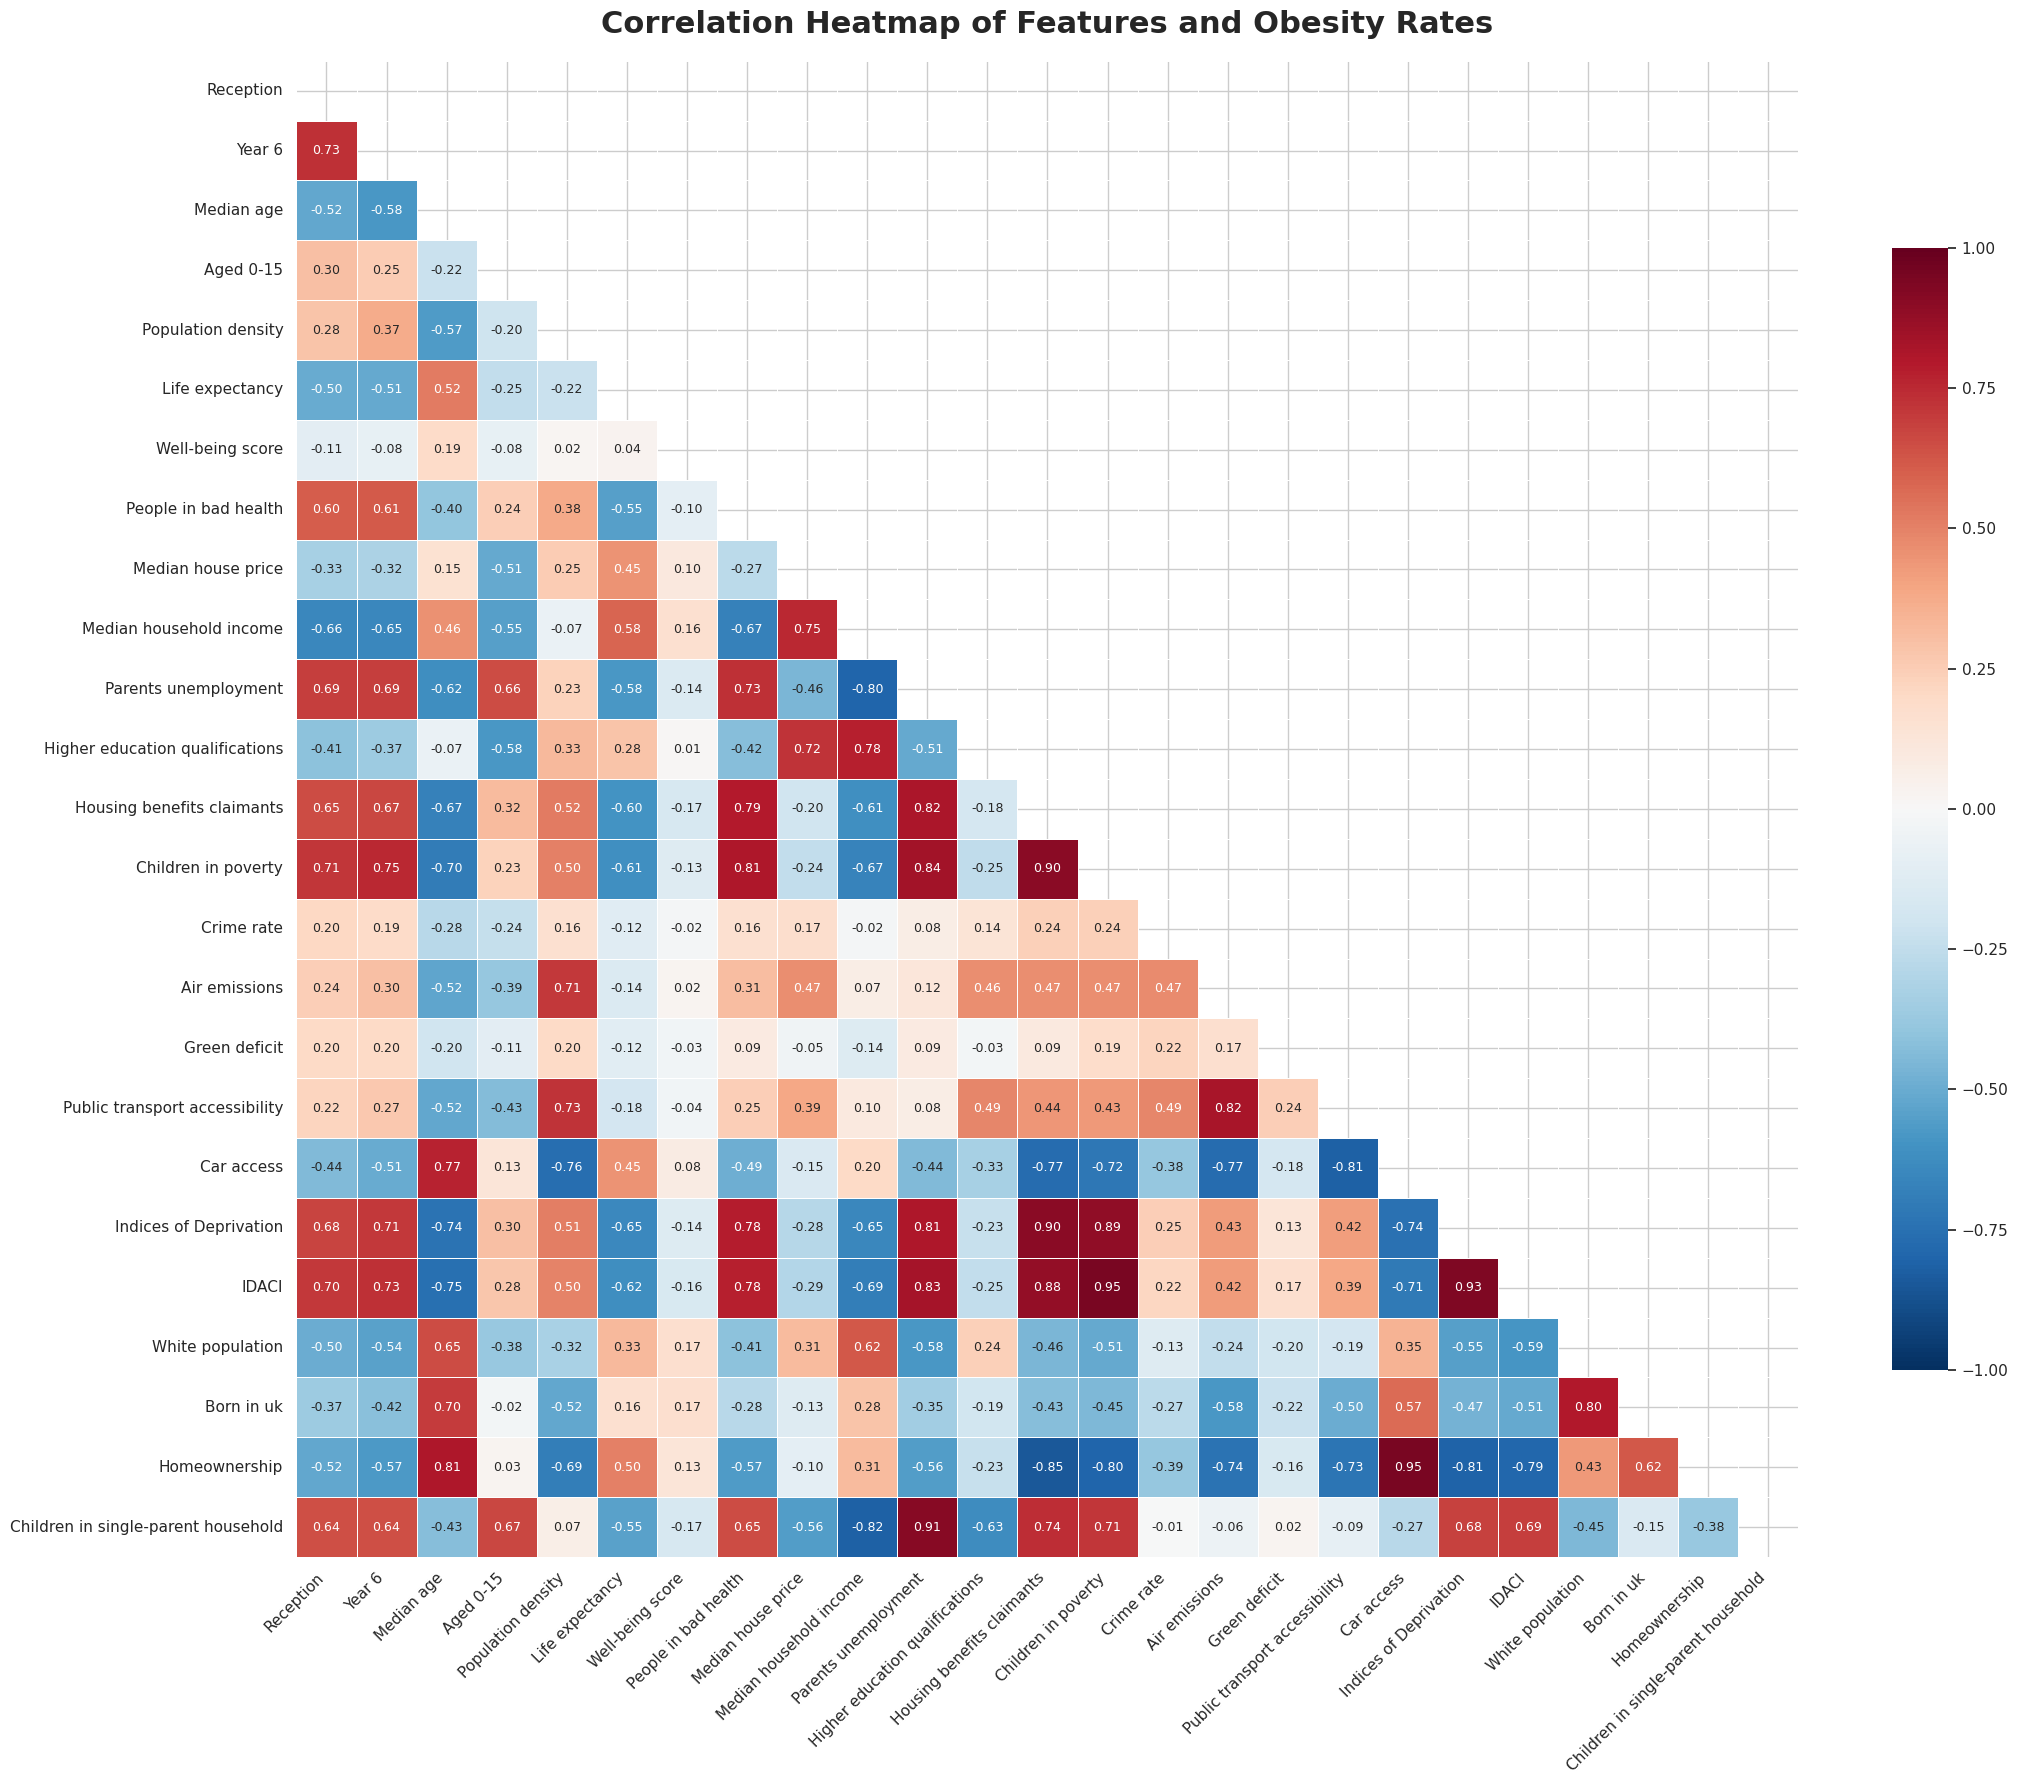

In [21]:
# Correlation Heatmap
# Using a lower-triangle heatmap for better readability with 23 features

# Filter numeric features (exclude strings, codes, or geometry columns)
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute the Pearson correlation matrix
corr_matrix = numeric_df.corr()

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set figure size
plt.figure(figsize=(22, 18))

# Plot the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,            
    cmap='RdBu_r',         
    annot=True,           
    fmt=".2f",             
    annot_kws={"size": 9},   
    linewidths=0.5,       
    vmin=-1, vmax=1,       
    cbar_kws={"shrink": .75} 
)

# Set title and axis labels
plt.title('Correlation Heatmap of Features and Obesity Rates', 
          fontsize=22, fontweight='bold', pad=20)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

The heatmap reveals that IDACI, Indices of Deprivation and Children in poverty are the strongly correlated with obesity. However, these variables are also heavily inter-correlated. IDACI and Indices of Deprivation share a coefficient of 0.95, indicating severe **multicollinearity**. To address this, **VIF analysis is applied to iteratively remove redundant features prior to modelling**.

## Methodology

[[ go back to the top ]](#Table-of-contents)

This study employs a four-stage analytical pipeline to address research questions.

To address RQ1, the pipeline begins with **Variance Inflation Factor (VIF)** analysis, which iteratively removes features exceeding a threshold of 10, ensuring retained predictors are sufficiently independent and regression coefficients remain reliable. **Multiple Linear Regression (MLR)** is then applied as an interpretable linear baseline, where coefficient estimates and p-values quantify each feature's linear contribution to obesity prevalence. Subsequently, **Random Forest (RF) and XGBoost** are employed to capture nonlinear relationships and feature interactions that MLR cannot model. Both are optimised via 5-fold cross-validation with GridSearchCV, and their predictive performance (R², RMSE) is compared against MLR to assess whether nonlinear models offer meaningful improvements.

To address RQ2, **SHAP** is applied to the best-performing model, decomposing its predictions into individual feature contributions. This transforms the otherwise opaque tree-based models into interpretable outputs, enabling a direct comparison of the marginal effects of key drivers between the Reception and Year 6 cohorts.

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

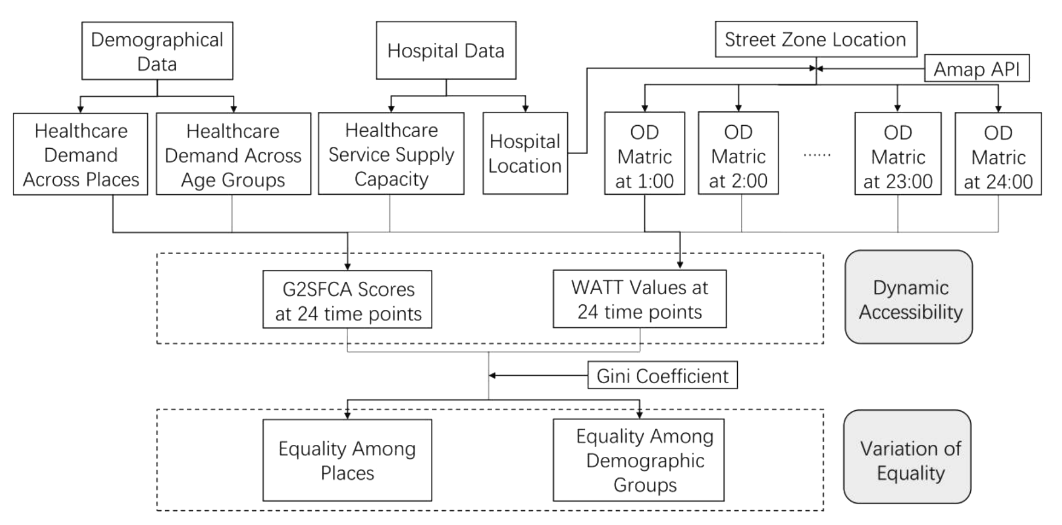

#### Variance Inflation Factor (VIF)

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

features_list = [
    'Median age', 'Aged 0-15', 'Population density', 'Life expectancy', 'Well-being score',
    'People in bad health', 'Median house price', 'Median household income', 'Parents unemployment',
    'Higher education qualifications', 'Housing benefits claimants', 'Children in poverty', 'Crime rate', 
    'Air emissions', 'Green deficit', 'Public transport accessibility', 'Car access', 
    'Indices of Deprivation', 'IDACI', 'White population', 'Born in uk', 
    'Homeownership', 'Children in single-parent household'
]

# Extract feature dataframe and drop any missing values
X = df[features_list].copy()
X = X.dropna()

# Define a function to iteratively calculate VIF and filter features
def calculate_vif_and_filter(X, threshold=5.0):
    X_with_const = add_constant(X)
    
    dropped_features = []
    
    while True:
        # Calculate VIF for all current features
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X_with_const.columns
        vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) 
                           for i in range(X_with_const.shape[1])]

        # Exclude the constant term
        vif_features = vif_data[vif_data['Feature'] != 'const']
        
        # Identify the feature with the highest VIF
        max_vif_row = vif_features.loc[vif_features['VIF'].idxmax()]
        max_vif_value = max_vif_row['VIF']
        max_vif_feature = max_vif_row['Feature']
        
        # Drop the feature if its VIF exceeds the threshold
        if max_vif_value > threshold:
            print(f"Dropping: {max_vif_feature} (VIF = {max_vif_value:.2f})")
            X_with_const = X_with_const.drop(columns=[max_vif_feature])
            dropped_features.append(max_vif_feature)
        else:
            break
            
    # Return the final selected features, the VIF dataframe, and dropped features
    final_vif = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False)
    return list(final_vif['Feature']), final_vif, dropped_features

# Set the VIF threshold and execute the function
vif_threshold = 10.0
final_features, final_vif_df, dropped = calculate_vif_and_filter(X, threshold=vif_threshold)

# Print final results
print("VIF threshold:", vif_threshold)
print("Number of VIF-selected features:", len(final_features))
display(final_vif_df)

Dropping: Homeownership (VIF = 30.93)
Dropping: Median household income (VIF = 27.70)
Dropping: Children in poverty (VIF = 25.37)
Dropping: Car access (VIF = 20.75)
Dropping: Parents unemployment (VIF = 19.59)
Dropping: Housing benefits claimants (VIF = 14.24)
Dropping: IDACI (VIF = 10.99)
VIF threshold: 10.0
Number of VIF-selected features: 16


,Feature,VIF
15,Born in uk,8.19
13,Indices of Deprivation,7.12
14,White population,7.06
1,Median age,5.83
10,Air emissions,5.31
12,Public transport accessibility,4.92
16,Children in single-parent household,4.68
8,Higher education qualifications,4.64
6,People in bad health,4.47
7,Median house price,3.89


#### Multiple Linear Regression (MLR)

In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = df[final_features]
y = df['Year 6']  # 这里以 Year 6 为例，你也可以换成 'Reception' 跑另一个模型

# 确保清除任何含有缺失值的行，保证 X 和 y 长度一致
mlr_data = pd.concat([X, y], axis=1).dropna()
X_clean = mlr_data[final_features]
y_clean = mlr_data['Year 6']

# 2. 划分训练集和测试集 (80% 训练，20% 测试)
# 这是为了后续能和随机森林/XGBoost 公平地对比预测能力！
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

# 3. 使用 statsmodels 构建 MLR 模型
# 注意：statsmodels 默认不带常数项（截距），我们需要手动加上去
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

# 拟合 OLS (Ordinary Least Squares) 模型
mlr_model = sm.OLS(y_train, X_train_sm).fit()

# 4. 打印极其详细的学术级统计摘要！
print(mlr_model.summary())

# 5. 在测试集上进行预测，计算机器学习评价指标
y_pred = mlr_model.predict(X_test_sm)

# 计算 RMSE 和 R²
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R-squared (R²): {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 Year 6   R-squared:                       0.637
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     51.51
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           1.62e-92
Time:                        17:30:08   Log-Likelihood:                -1238.2
No. Observations:                 487   AIC:                             2510.
Df Residuals:                     470   BIC:                             2582.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

简单描述一下

#### Random Forest (RF)

开始进行交叉验证和超参数搜索，请稍候...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

====================== CV 寻优结果 ======================
最佳超参数组合 (Best Parameters):
 - max_depth: 10
 - min_samples_leaf: 2
 - min_samples_split: 2
 - n_estimators: 300

====================== Best RF 测试集预测性能 ======================
R-squared (R²): 0.6822
RMSE: 2.6925


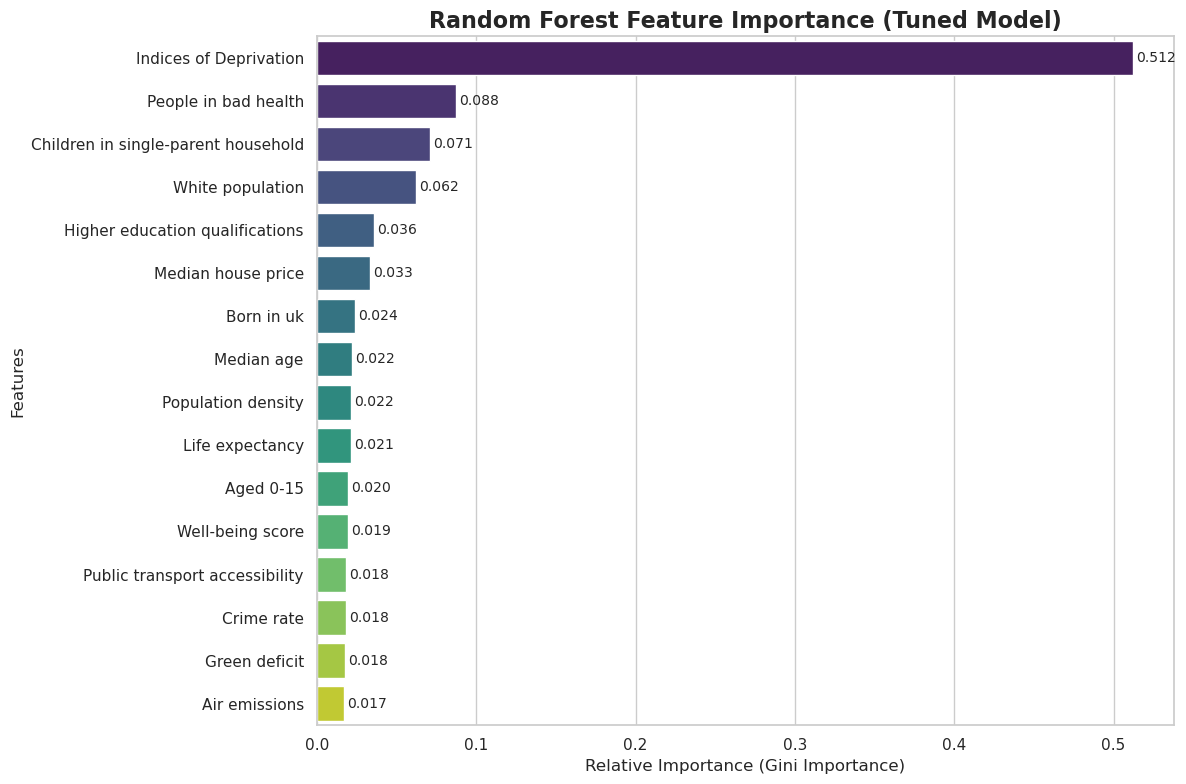

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ==========================================
# 1. 定义超参数搜索网格 (Hyperparameter Grid)
# ==========================================
# 你可以根据电脑算力增加或减少候选值
param_grid = {
    'n_estimators': [100, 300, 500],      # 树的数量
    'max_depth': [10, 15, 20, None],      # 树的最大深度 (None表示不限制)
    'min_samples_split': [2, 5, 10],      # 分裂内部节点所需的最小样本数
    'min_samples_leaf': [1, 2, 4]         # 叶子节点所需的最小样本数
}

# 2. 初始化基础随机森林模型
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

# ==========================================
# 3. 设置 5 折交叉验证 (5-Fold CV)
# ==========================================
# cv=5: 将训练集分成5份，轮流用4份训练1份验证
# verbose=1: 运行时打印进度条
print("开始进行交叉验证和超参数搜索，请稍候...")
grid_search = GridSearchCV(
    estimator=rf_base, 
    param_grid=param_grid, 
    cv=5, 
    n_jobs=-1,
    scoring='r2', 
    verbose=1
)

# 4. 在训练集上拟合 CV
grid_search.fit(X_train, y_train)

# 5. 提取出交叉验证选出的【最佳模型】和【最佳参数】
best_rf_model = grid_search.best_estimator_

print("\n====================== CV 寻优结果 ======================")
print("最佳超参数组合 (Best Parameters):")
for key, value in grid_search.best_params_.items():
    print(f" - {key}: {value}")

# ==========================================
# 6. 使用最佳模型在测试集上进行最终预测
# ==========================================
rf_y_pred = best_rf_model.predict(X_test)

# 计算并打印评估指标
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print("\n====================== Best RF 测试集预测性能 ======================")
print(f"R-squared (R²): {rf_r2:.4f}")
print(f"RMSE: {rf_rmse:.4f}")

# ==========================================
# 7. 绘制特征重要性图 (基于最佳模型)
# ==========================================
importances = best_rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)

plt.title('Random Forest Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance (Gini Importance)', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 在柱子旁添加数值
for index, value in enumerate(importance_df['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### XGBoost

In [25]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 MB 29.5 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 31.5 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


开始进行 XGBoost 交叉验证和超参数搜索，请稍候...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

====================== XGBoost CV 寻优结果 ======================
最佳超参数组合 (Best Parameters):
 - colsample_bytree: 0.8
 - learning_rate: 0.01
 - max_depth: 5
 - n_estimators: 500
 - subsample: 0.8

====================== Best XGBoost 测试集预测性能 ======================
R-squared (R²): 0.6831
RMSE: 2.6887


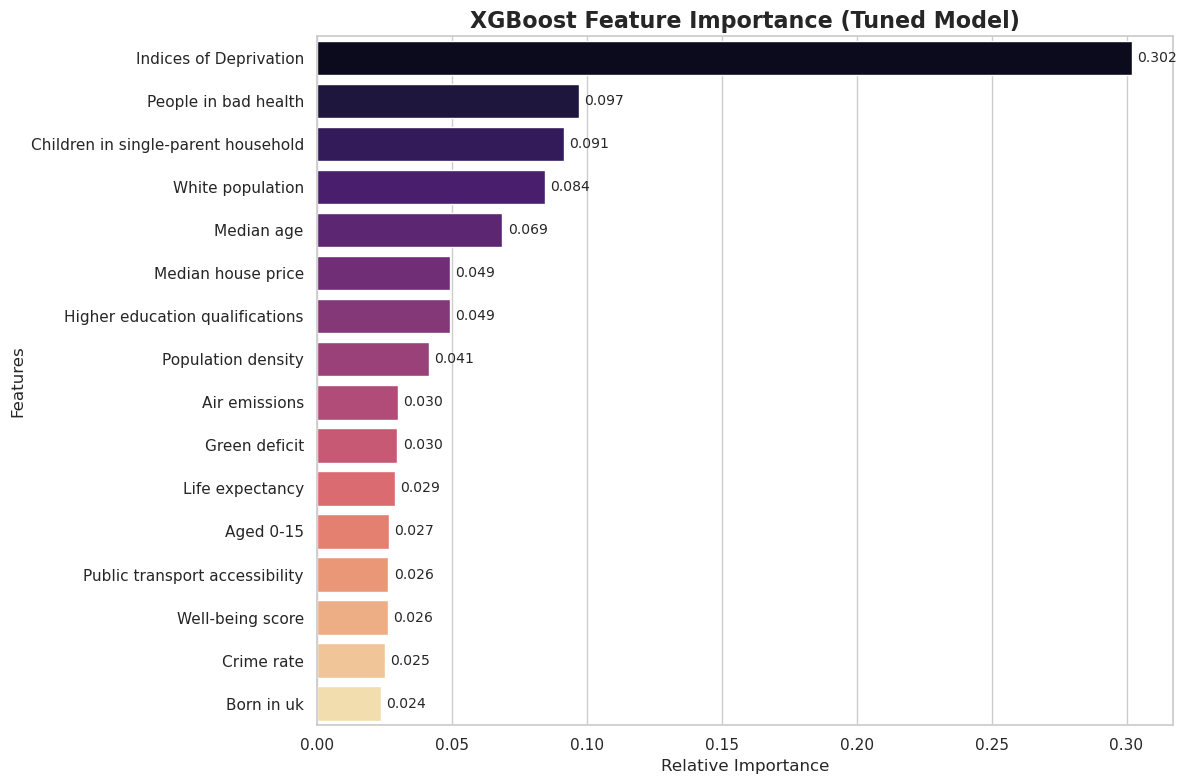

In [26]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# ==========================================
# 1. 定义 XGBoost 的超参数搜索网格
# ==========================================
# XGBoost 很容易在小数据集上过拟合，所以 max_depth 通常设置得比 RF 浅
param_grid_xgb = {
    'n_estimators': [100, 300, 500],        # 迭代次数 (树的数量)
    'max_depth': [3, 5, 7],                 # 每棵树的最大深度
    'learning_rate': [0.01, 0.05, 0.1],     # 学习率 (步长)，越小越稳但需要更多树
    'subsample': [0.8, 1.0],                # 样本采样率 (每次建树用多少比例的数据)
    'colsample_bytree': [0.8, 1.0]          # 特征采样率 (每次建树用多少比例的特征)
}

# 2. 初始化基础 XGBoost 模型
# objective='reg:squarederror' 是标准的回归损失函数
xgb_base = xgb.XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')

# ==========================================
# 3. 设置 5 折交叉验证 (5-Fold CV)
# ==========================================
print("开始进行 XGBoost 交叉验证和超参数搜索，请稍候...")
grid_search_xgb = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid_xgb, 
    cv=5, 
    n_jobs=-1, 
    scoring='r2', 
    verbose=1
)

# 4. 在训练集上拟合 CV
grid_search_xgb.fit(X_train, y_train)

# 5. 提取出最佳模型和最佳参数
best_xgb_model = grid_search_xgb.best_estimator_

print("Best Parameters:")
for key, value in grid_search_xgb.best_params_.items():
    print(f" - {key}: {value}")

# ==========================================
# 6. 测试集预测与评估
# ==========================================
xgb_y_pred = best_xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_y_pred))
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("\n====================== Best XGBoost 测试集预测性能 ======================")
print(f"R-squared (R²): {xgb_r2:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")

# ==========================================
# 7. 绘制 XGBoost 特征重要性图
# ==========================================
importances_xgb = best_xgb_model.feature_importances_
feature_names = X_train.columns

importance_df_xgb = pd.DataFrame({'Feature': feature_names, 'Importance': importances_xgb})
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
# 使用了 hue='Feature' 和 legend=False，完美避开之前的警告，并使用了 'magma' 暖色系调色板以示区分
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb, hue='Feature', palette='magma', legend=False)

plt.title('XGBoost Feature Importance (Tuned Model)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)

# 在柱子旁添加数值
for index, value in enumerate(importance_df_xgb['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

#### Model Performance Comparison

In [27]:
import pandas as pd
from IPython.display import display, Markdown

# 1. 将所有模型的跑分变量汇总到一个字典中
# 注意：这里使用的变量名 r2, rmse, rf_r2 等，必须和你之前代码里定义的一致！
results_data = {
    'Model': [
        'Multiple Linear Regression (MLR)', 
        'Random Forest (Tuned)', 
        'XGBoost (Tuned)'
    ],
    'R-squared (R²)': [r2, rf_r2, xgb_r2],
    'RMSE': [rmse, rf_rmse, xgb_rmse],
    'Model Type': [
        'Linear / Baseline', 
        'Non-linear / Ensemble (Bagging)', 
        'Non-linear / Ensemble (Boosting)'
    ]
}

# 2. 转换为 Pandas DataFrame
results_df = pd.DataFrame(results_data)

# 3. 将数字格式化为保留 4 位小数（让表格看起来整齐专业）
results_df['R-squared (R²)'] = results_df['R-squared (R²)'].apply(lambda x: f"{x:.4f}")
results_df['RMSE'] = results_df['RMSE'].apply(lambda x: f"{x:.4f}")

# 4. 把 Model 列设为索引，这样表格左侧就不会有丑丑的 0,1,2 序号了
results_df.set_index('Model', inplace=True)

display(results_df)

# ------------------------------------------------------------------
# (可选附加功能) 自动生成 Markdown 文本，方便你复制粘贴到最终的报告文档里
# ------------------------------------------------------------------
print("\n--- 如果你需要复制到 Markdown 单元格，请直接复制下面这段代码 ---")
markdown_table = results_df.to_markdown()
print(markdown_table)

================ Model Performance Comparison ================


,R-squared (R²),RMSE,Model Type
Model,,,
Multiple Linear Regression (MLR),0.6756,2.7200,Linear / Baseline
Random Forest (Tuned),0.6822,2.6925,Non-linear / Ensemble (Bagging)
XGBoost (Tuned),0.6831,2.6887,Non-linear / Ensemble (Boosting)



--- 如果你需要复制到 Markdown 单元格，请直接复制下面这段代码 ---
| Model                            |   R-squared (R²) |   RMSE | Model Type                       |
|:---------------------------------|-----------------:|-------:|:---------------------------------|
| Multiple Linear Regression (MLR) |           0.6756 | 2.72   | Linear / Baseline                |
| Random Forest (Tuned)            |           0.6822 | 2.6925 | Non-linear / Ensemble (Bagging)  |
| XGBoost (Tuned)                  |           0.6831 | 2.6887 | Non-linear / Ensemble (Boosting) |


#### SHAP

In [28]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 9.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 MB 27.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 17.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]


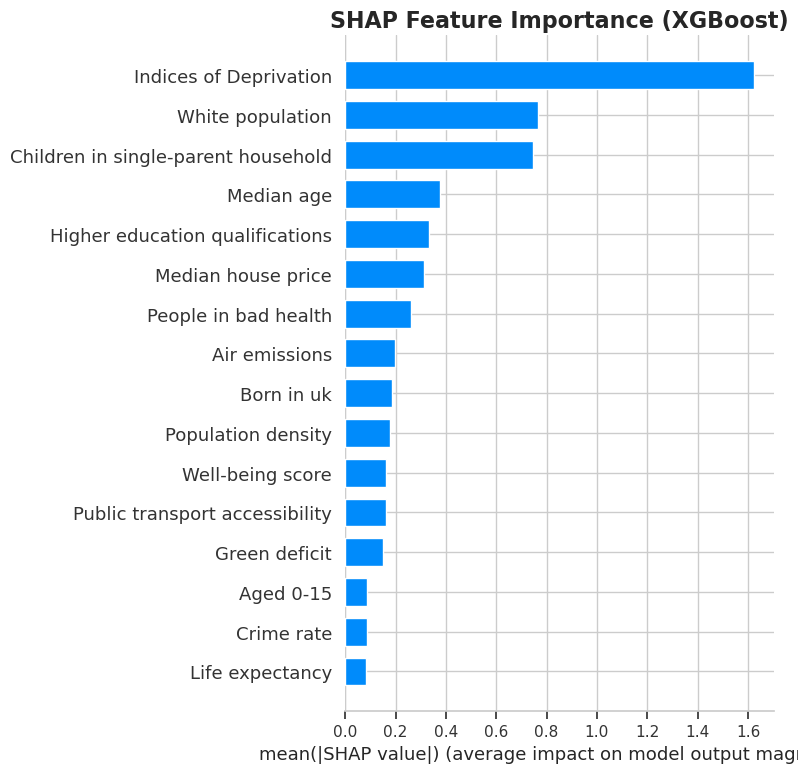

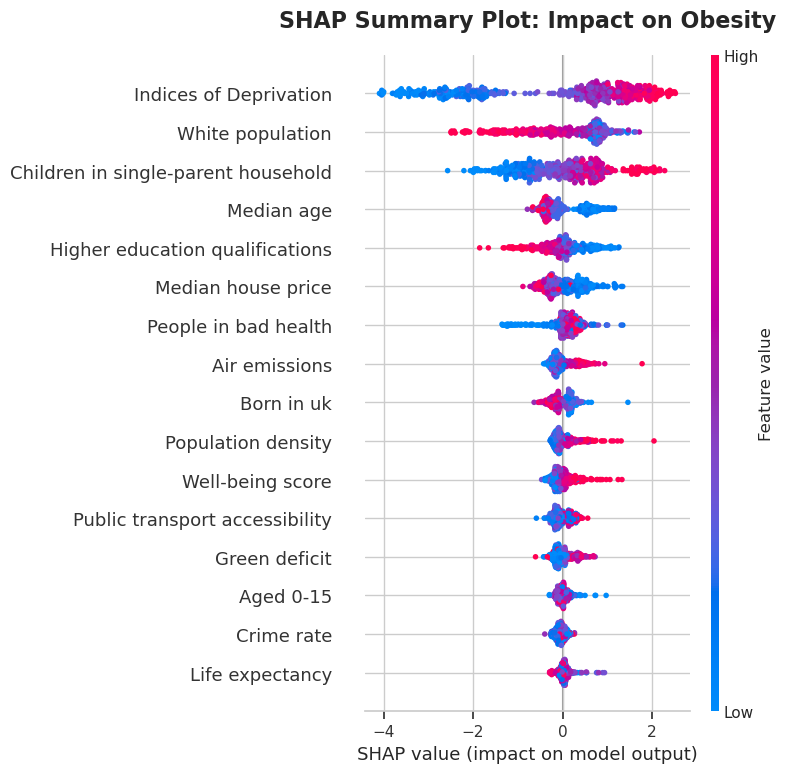

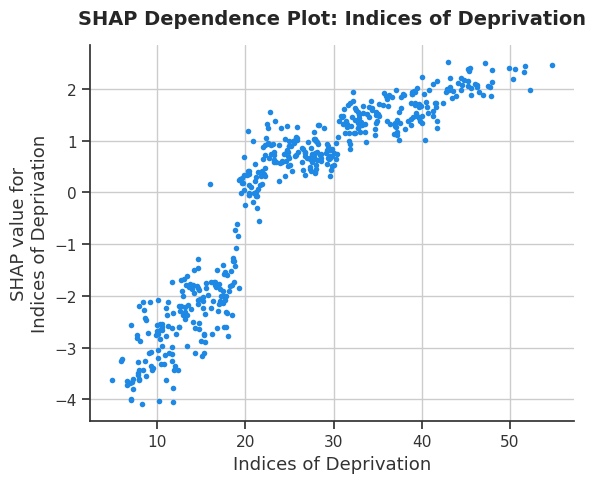

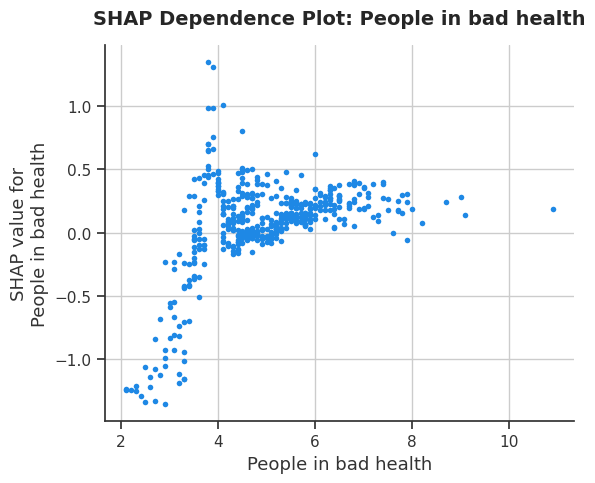

In [29]:
import shap
import matplotlib.pyplot as plt

# 1. 初始化 SHAP 解释器 (TreeExplainer 专用于树模型，速度极快)
# 请确保传入的是你刚才通过交叉验证得出的 best_xgb_model
explainer = shap.TreeExplainer(best_xgb_model)

# 2. 计算训练集的 SHAP 值 
# (用 X_train 来做全局解释可以最大程度反映模型学到的整体规律)
shap_values = explainer.shap_values(X_train)

# ==========================================
# 图 1：SHAP 全局特征重要性柱状图 (Bar Plot)
# ==========================================
plt.figure(figsize=(10, 6))
# show=False 允许我们自定义图表标题和布局
shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (XGBoost)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 图 2：SHAP 摘要图/蜂群图 (Beeswarm Plot) —— 核心神图！
# ==========================================
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train, show=False)
plt.title("SHAP Summary Plot: Impact on Obesity", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ==========================================
# 图 3：单变量依赖图 (Dependence Plot) —— 探索非线性关系
# ==========================================
# 这里以排名前两名的特征为例，请确保列名与你的数据完全一致！
top_feature_1 = 'Indices of Deprivation'
top_feature_2 = 'People in bad health'

# 绘制排名第一特征的依赖图
shap.dependence_plot(top_feature_1, shap_values, X_train, interaction_index=None, show=False)
plt.title(f"SHAP Dependence Plot: {top_feature_1}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# 绘制排名第二特征的依赖图
shap.dependence_plot(top_feature_2, shap_values, X_train, interaction_index=None, show=False)
plt.title(f"SHAP Dependence Plot: {top_feature_2}", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

[[ go back to the top ]](#Table-of-contents)

In [30]:
end_time = time.time() 
run_time = end_time - start_time 
print("Total run time: ", run_time, "seconds")

Total run time:  153.09253191947937 seconds


## References

[[ go back to the top ]](#Table-of-contents)

Colmenarejo, G. (2020) ‘Machine Learning Models to Predict Childhood and Adolescent Obesity: A Review’, Nutrients, 12(8). Available at: https://doi.org/10.3390/nu12082466.

National Child Measurement Programme annual report, academic year 2024 to 2025 (no date). Available at: https://fingertips.phe.org.uk/static-reports/obesity-physical-activity-nutrition/national-child-measurement-programme-2024-2025-academic-year.html (Accessed: 8 April 2026).

Pei, Z. et al. (2013) ‘Early life risk factors of being overweight at 10 years of age: results of the German birth cohorts GINIplus and LISAplus’, European Journal of Clinical Nutrition, 67(8), pp. 855–862. Available at: https://doi.org/10.1038/ejcn.2013.80.

Hammond R. et al. (2019) ‘Predicting childhood obesity using electronic health records and publicly available data’, PLOS ONE, 14(4), p. e0215571. Available at: https://doi.org/10.1371/journal.pone.0215571.

Jeong, S. et al. (2023) ‘Understanding cross-data dynamics of individual and social/environmental factors through a public health lens: explainable machine learning approaches’, Frontiers in Public Health, 11. Available at: https://doi.org/10.3389/fpubh.2023.1257861.

Mazza, O. et al. (2025) ‘Spatial patterns of childhood obesity clusters linked to socioeconomic inequalities’, Frontiers in Public Health, 13. Available at: https://doi.org/10.3389/fpubh.2025.1497090.

Salerno, P.R.V.O. et al. (2024) ‘County-level socio-environmental factors and obesity prevalence in the United States’, Diabetes, Obesity and Metabolism, 26(5), pp. 1766–1774. Available at: https://doi.org/10.1111/dom.15488.
